# Inverse Design of a Polarization-Basis 2×2 Unitary Operator (MEEP)

MEEP port of `polarization_unitary.ipynb` (Tidy3D original).

Runs a full 3-D SOI simulation (220 nm Si / 1 µm SiO₂ BOX / air cladding)  
and uses `meep.adjoint` to inverse-design a patterned-Si region that  
implements a chosen 2×2 unitary on the (TE₀, TM₀) polarization qubit.

**Setup (WSL/Ubuntu):**
```
conda install -c conda-forge pymeep=*=mpi_mpich_* nlopt scipy matplotlib
```


In [1]:
# Section 1 — Imports
import os
import pickle
import warnings

import autograd.numpy as anp
import matplotlib.pyplot as plt
import nlopt
import numpy as np
import scipy.ndimage as ndi
import scipy.signal as ssg

import meep as mp
import meep.adjoint as mpa

warnings.filterwarnings("ignore")
mp.verbosity(1)   # set to 1 for full FDTD diagnostics

print(f"MEEP  version : {mp.__version__}")
print(f"NumPy version : {np.__version__}")


Using MPI version 4.1, 1 processes
MEEP  version : 1.33.0
NumPy version : 2.4.6


In [2]:
# Section 2 — Physical parameters  (all lengths in µm; 1 MEEP unit = 1 µm)

# Wavelength / frequency
wl   = 1.55          # µm
fcen = 1.0 / wl      # MEEP natural frequency
df   = 0.02 * fcen   # Gaussian pulse width (kept narrow to approximate CW)

# Materials
n_Si   = 3.476
n_SiO2 = 1.444
eps_Si   = n_Si**2
eps_SiO2 = n_SiO2**2
eps_air  = 1.0

Si   = mp.Medium(epsilon=eps_Si)
SiO2 = mp.Medium(epsilon=eps_SiO2)
Air  = mp.Medium(epsilon=eps_air)

# Waveguide cross-section (standard 220 nm SOI)
t_Si  = 0.22         # Si layer thickness
w_wg  = 0.50         # waveguide width — supports both TE₀ and TM₀
t_BOX = 1.0          # SiO₂ BOX thickness

# Design region
dr_lx = 4.0          # design region length in x (µm)
dr_ly = 2.5          # design region width in y (µm)

# Resolution: 14 px/µm → ~70 nm pixels; Si slab = ~3 cells thick.
# At least 10 is required (slab ≥ 2 cells). 14 matches the working v3 value.
global_res = 14      # px/µm
dr_res = global_res

# Calculate exact integer pixel counts and snap sizes to avoid MEEP warnings
Nx = int(round(dr_lx * global_res))
Ny = int(round(dr_ly * global_res))
dr_lx = Nx / global_res   # re-snap to exact grid
dr_ly = Ny / global_res

# Waveguide stub length on each side of the design region (inside the cell)
stub_len = 1.0

# PML thickness
dpml = 1.0

# Fabrication filter
min_feature = 0.10   # 100 nm
filter_R    = min_feature

# Optimisation
opt_steps = 5
lambda_pen_max = 0.5

# Projection sharpness schedule
beta_min = 1.0
beta_max = 32.0
beta_ramp_start = int(opt_steps * 0.2)

os.makedirs("misc", exist_ok=True)
history_fname = "misc/polarization_unitary_meepv5_history.pkl"

print(f"Design region : {dr_lx} µm × {dr_ly} µm")
print(f"Grid          : {Nx} × {Ny} = {Nx*Ny:,} parameters")
print(f"Resolution    : {global_res} px/µm  (Si slab = {t_Si*global_res:.1f} cells thick)")


Design region : 4.0 µm × 2.5 µm
Grid          : 56 × 35 = 1,960 parameters
Resolution    : 14 px/µm  (Si slab = 3.1 cells thick)


In [3]:
# Section 3 — Derived geometry quantities with strict pixel snapping

Npar = Nx * Ny

# Force the entire cell dimensions to snap perfectly to integer pixel counts
sx_raw = dr_lx + 2*stub_len + 2*dpml
sy_raw = dr_ly  + 2*dpml
sz_raw = t_Si   + t_BOX + 2*dpml

cell_nx = int(round(sx_raw * global_res))
cell_ny = int(round(sy_raw * global_res))
cell_nz = int(round(sz_raw * global_res))

sx = cell_nx / global_res
sy = cell_ny / global_res
sz = cell_nz / global_res

cell = mp.Vector3(sx, sy, sz)

# z-coordinates (MEEP cell centred at z = 0, aligned to mid-Si-slab)
z_si_top  =  t_Si / 2
z_si_bot  = -t_Si / 2
z_box_bot = z_si_bot - t_BOX

# Source / monitor x-positions (centred in stub, clear of PML)
src_x = -(dr_lx/2 + stub_len/2)
mon_x =  (dr_lx/2 + stub_len/2)

# Monitor cross-section (y × z) — large enough to capture both guided modes
mon_y = dr_ly
mon_z = t_Si + t_BOX + 0.4   # a bit of air on top too

# Interface-buffer dimensions in design-grid pixels
n_border_x  = max(2, int(round(0.16 * dr_res)))
n_wg_half_y = max(1, int(round((w_wg / 2) * dr_res)))
n_cy        = Ny // 2

print(f"Design grid : {Nx} × {Ny} = {Npar:,} parameters")
print(f"Cell size : {sx:.2f} × {sy:.2f} × {sz:.2f} µm")
print(f"src_x = {src_x:.3f} µm,  mon_x = {mon_x:.3f} µm")
print(f"Buffer: {n_border_x} px in x | WG half-width: {n_wg_half_y} px in y")


Design grid : 56 × 35 = 1,960 parameters
Cell size : 8.00 × 4.50 × 3.21 µm
src_x = -2.500 µm,  mon_x = 2.500 µm
Buffer: 2 px in x | WG half-width: 4 px in y


In [4]:
# Section 4 — Static geometry (BOX + waveguide stubs)
#
# The design-region block is added separately in each simulation so the
# MaterialGrid can be updated without rebuilding static structures.

def static_geometry():
    """Return list of mp.GeometricObject for the fixed (non-design) structures."""
    INF = 1e6

    # SiO₂ BOX (below the Si slab)
    box_layer = mp.Block(
        size   = mp.Vector3(INF, INF, t_BOX),
        center = mp.Vector3(0, 0, z_si_bot - t_BOX/2),
        material = SiO2,
    )

    # Left input-waveguide stub: x ∈ [-sx/2, -dr_lx/2]
    # Extend 0.01 µm into the design boundary to avoid a gap.
    stub_half_x = (sx/2 - dr_lx/2 + 0.01) / 2
    wg_in = mp.Block(
        size   = mp.Vector3(sx/2 - dr_lx/2 + 0.02, w_wg, t_Si),
        center = mp.Vector3(-(dr_lx/2 + stub_half_x), 0, 0),
        material = Si,
    )

    # Right output-waveguide stub: x ∈ [dr_lx/2, sx/2]
    wg_out = mp.Block(
        size   = mp.Vector3(sx/2 - dr_lx/2 + 0.02, w_wg, t_Si),
        center = mp.Vector3( (dr_lx/2 + stub_half_x), 0, 0),
        material = Si,
    )

    return [box_layer, wg_in, wg_out]

print("static_geometry() defined — SiO₂ BOX + WG-in + WG-out")


static_geometry() defined — SiO₂ BOX + WG-in + WG-out


In [5]:
# Section 5 — Parameter preprocessing pipeline
#
# 1. interface_buffer  — force rho=1 in a WG-width strip at left/right edges
# 2. conic_filter      — spatial blur to enforce ≥100 nm minimum feature size
# 3. tanh projection   — drive pixels toward 0 or 1 (sharpness β)
# Applied twice (filter+project)×2 for cleaner binarisation.
#
# The adjoint chain rule through the pipeline is implemented analytically
# in pre_process_grad().

def _make_conic_kernel(radius_um, res_pxum):
    r_px = int(np.ceil(radius_um * res_pxum))
    sz_k = 2 * r_px + 1
    k    = np.zeros((sz_k, sz_k))
    for i in range(sz_k):
        for j in range(sz_k):
            d = np.sqrt((i - r_px)**2 + (j - r_px)**2) / (r_px + 1e-9)
            if d <= 1.0:
                k[i, j] = 1.0 - d
    k /= k.sum()
    return k

_conic_k = _make_conic_kernel(filter_R, dr_res)

def conic_filter(rho2d):
    return ssg.convolve2d(rho2d, _conic_k, mode="same", boundary="fill", fillvalue=0.0)

def tanh_proj(rho2d, beta):
    t = np.tanh(beta * 0.5)
    return 0.5 + 0.5 * np.tanh(beta * (rho2d - 0.5)) / t

def dtanh_proj(rho2d, beta):
    """Elementwise derivative of tanh_proj w.r.t. rho2d."""
    t = np.tanh(beta * 0.5)
    return 0.5 * beta * (1.0 - np.tanh(beta * (rho2d - 0.5))**2) / t

def interface_buffer(p2d):
    """Force rho=1 in the waveguide-width strip at the left/right edges."""
    p = p2d.copy()
    y0 = n_cy - n_wg_half_y
    y1 = n_cy + n_wg_half_y + 1
    p[0          : n_border_x,  y0:y1] = 1.0
    p[Nx - n_border_x : Nx,    y0:y1] = 1.0
    return p

def pre_process(params_flat, beta):
    """Return flattened pre-processed density in [0,1], shape (Npar,)."""
    p = params_flat.reshape(Nx, Ny)
    p = interface_buffer(p)
    p = conic_filter(p);  p = tanh_proj(p, beta)
    p = conic_filter(p);  p = tanh_proj(p, beta)
    return p.ravel()

def pre_process_grad(params_flat, grad_rho_flat, beta):
    """Back-propagate grad_rho_flat (dJ/d rho_processed) → dJ/d params_flat."""
    p0 = interface_buffer(params_flat.reshape(Nx, Ny))
    f1 = conic_filter(p0);      p1 = tanh_proj(f1, beta)
    f2 = conic_filter(p1)
    # grad comes in as dJ/d p2 (after second tanh_proj)
    g  = grad_rho_flat.reshape(Nx, Ny)
    g  = g * dtanh_proj(f2, beta)                                   # through 2nd tanh
    g  = ssg.convolve2d(g, _conic_k, mode="same", boundary="fill", fillvalue=0.0)  # through 2nd filter
    g  = g * dtanh_proj(f1, beta)                                   # through 1st tanh
    g  = ssg.convolve2d(g, _conic_k, mode="same", boundary="fill", fillvalue=0.0)  # through 1st filter
    # Zero out interface-buffer pixels (their params are not free variables)
    y0, y1 = n_cy - n_wg_half_y, n_cy + n_wg_half_y + 1
    g[0:n_border_x, y0:y1]          = 0.0
    g[Nx-n_border_x:Nx, y0:y1]     = 0.0
    return g.ravel()

print(f"Conic kernel: {_conic_k.shape[0]}×{_conic_k.shape[1]} px  "
      f"(radius={filter_R} µm at {dr_res} px/µm)")


Conic kernel: 5×5 px  (radius=0.1 µm at 14 px/µm)


In [6]:
# Section 6 — Erosion-dilation fabrication penalty
#
# penalty = mean( rho_eroded · (1 − rho_dilated) )
# = 0 when all pixels are 0 or 1, > 0 when gray pixels exist.
# The smooth erosion/dilation approximations follow Lazarov et al. (2016).

def fab_penalty(params_flat, beta, beta_ed=8.0):
    rho = pre_process(params_flat, beta).reshape(Nx, Ny)
    # Smooth erosion: complement, filter, complement
    rho_ero = tanh_proj(conic_filter(1.0 - rho), beta_ed)
    rho_ero = 1.0 - rho_ero
    # Smooth dilation: filter, project
    rho_dil = tanh_proj(conic_filter(rho), beta_ed)
    return float(np.mean(rho_ero * (1.0 - rho_dil)))

print("fab_penalty() defined.")


fab_penalty() defined.


In [7]:
# Section 7 — Mode-index calibration
#
# MEEP EigenModeSource sorts modes by descending Re(neff).
# For 220 nm × 500 nm Si-on-SiO₂ at 1550 nm:
#   band 1 → TE₀  (Ey-dominant, neff ≈ 2.4)
#   band 2 → TM₀  (Ez-dominant, neff ≈ 1.7)
#
# We verify by sampling the eigenmode field inside the waveguide core.

eig_band_TE = 1   # updated by calibrate_modes()
eig_band_TM = 2

def calibrate_modes():
    """Empirically assign eig_band_TE and eig_band_TM."""
    global eig_band_TE, eig_band_TM

    # Minimal geometry: just the waveguide cross-section for eigenmode solve.
    wg_geom = [
        mp.Block(size=mp.Vector3(1e6, 1e6, t_BOX),
                 center=mp.Vector3(0, 0, z_si_bot - t_BOX/2), material=SiO2),
        mp.Block(size=mp.Vector3(1e6, w_wg, t_Si),
                 center=mp.Vector3(0, 0, 0), material=Si),
    ]
    # Minimal cell (thin in x since we only need the cross-section)
    cal_cell = mp.Vector3(0.2, sy, sz)
    cal_pml  = [mp.PML(dpml, direction=mp.Y), mp.PML(dpml, direction=mp.Z)]

    dummy_src = [mp.EigenModeSource(
        src=mp.GaussianSource(fcen, fwidth=df*10),
        center=mp.Vector3(0, 0, 0),
        size=mp.Vector3(0, mon_y, mon_z),
        eig_band=1,
    )]

    sim_cal = mp.Simulation(
        cell_size=cal_cell,
        boundary_layers=cal_pml,
        geometry=wg_geom,
        sources=dummy_src,
        resolution=global_res,
    )
    sim_cal.init_sim()

    mon_vol = mp.Volume(center=mp.Vector3(0, 0, 0),
                        size=mp.Vector3(0, mon_y, mon_z))

    results = {}
    for band in [1, 2]:
        em = sim_cal.get_eigenmode(fcen, mp.X, mon_vol, band, mp.Vector3(1, 0, 0))
        # Sample |Ey|² and |Ez|² on a small grid inside the waveguide core
        ys = np.linspace(-w_wg/2*0.9, w_wg/2*0.9, 8)
        zs = np.linspace(-t_Si/2*0.9, t_Si/2*0.9, 4)
        Ey2, Ez2 = 0.0, 0.0
        for y in ys:
            for z in zs:
                pt = mp.Vector3(0, y, z)
                Ey2 += abs(em.amplitude(pt, mp.Ey))**2
                Ez2 += abs(em.amplitude(pt, mp.Ez))**2
        te_frac = Ey2 / (Ey2 + Ez2 + 1e-30)
        neff    = em.kdom.x / fcen
        results[band] = (te_frac, neff)
        print(f"  band {band}: neff={neff:.4f}  |Ey|² frac={te_frac:.3f}")

    # Assign TE to the band with larger |Ey|² fraction
    eig_band_TE = 1 if results[1][0] >= results[2][0] else 2
    eig_band_TM = 3 - eig_band_TE
    print(f"\n  → eig_band_TE={eig_band_TE},  eig_band_TM={eig_band_TM}")
    return eig_band_TE, eig_band_TM

print("Running mode calibration…")
eig_band_TE, eig_band_TM = calibrate_modes()


Running mode calibration…
-----------
Initializing structure...
time for choose_chunkdivision = 9.2338e-05 s
Working in 3D dimensions.
Computational cell is 0.214286 x 4.5 x 3.21429 with resolution 14
     block, center = (0,0,-0.61)
          size (1e+06,1e+06,1)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.08514,2.08514,2.08514)
     block, center = (0,0,0)
          size (1e+06,0.5,0.22)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.0826,12.0826,12.0826)
time for set_epsilon = 0.0294186 s
-----------


MPB solved for frequency_1(2.24258,0,0) = 0.875042 after 24 iters
MPB solved for frequency_1(1.344,0,0) = 0.651743 after 14 iters
MPB solved for frequency_1(1.31657,0,0) = 0.645168 after 11 iters
MPB solved for frequency_1(1.31654,0,0) = 0.645161 after 4 iters


MPB solved for frequency_1(1,0,0) = 0.56946 after 20 iters
MPB solved for frequency_1(1.31167,0,0) = 0.643994 after 14 iters
MPB solved for frequency_1(1.31655,0,0) = 0.645161 after 9 iters
MPB solved for frequency_1(1.31654,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.316545,-0.000000,0.000000)


  band 1: neff=2.0406  |Ey|² frac=0.989
MPB solved for frequency_2(1,0,0) = 0.691688 after 29 iters
MPB solved for frequency_2(0.89716,0,0) = 0.642403 after 19 iters
MPB solved for frequency_2(0.902614,0,0) = 0.645154 after 14 iters
MPB solved for frequency_2(0.902629,0,0) = 0.645161 after 6 iters
MPB solved for frequency_2(0.902629,0,0) = 0.645161 after 1 iters
Dominant planewave for band 2: (0.902629,-0.000000,0.000000)
  band 2: neff=1.3991  |Ey|² frac=0.115

  → eig_band_TE=1,  eig_band_TM=2


In [8]:
# Section 8 — Target unitary

def hadamard():
    return (1.0/np.sqrt(2)) * np.array([[1, 1],[1,-1]], dtype=complex)

def pauli_x():
    return np.array([[0,1],[1,0]], dtype=complex)

def pauli_z():
    return np.array([[1,0],[0,-1]], dtype=complex)

def rotator(alpha):
    c, s = np.cos(alpha), np.sin(alpha)
    return np.array([[c,-s],[s,c]], dtype=complex)

def retarder(phi):
    return np.array([[1,0],[0,np.exp(1j*phi)]], dtype=complex)

def is_unitary(U, tol=1e-9):
    return np.allclose(U.conj().T @ U, np.eye(2), atol=tol)

# ── Choose target here ────────────────────────────────────────────────────────
# U_target = pauli_x()              # TE ↔ TM swap
# U_target = rotator(np.pi/4)       # 45° polarisation rotator
U_target = hadamard()

assert is_unitary(U_target), "U_target is not unitary!"
print("U_target (Hadamard) =")
print(np.round(U_target, 4))


U_target (Hadamard) =
[[ 0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j]]


In [9]:
# Section 9 — Build one OptimizationProblem per input polarization
#
# MEEP adjoint API pattern:
#
#   design_vars = mp.MaterialGrid(...)   # weights ∈ [0,1]: 0=Air, 1=Si
#   dr = mpa.DesignRegion(design_parameters=design_vars, volume=...)
#   te_mon = mpa.EigenmodeCoefficient(sim, vol, mode=eig_band_TE)
#   tm_mon = mpa.EigenmodeCoefficient(sim, vol, mode=eig_band_TM)
#
#   def obj(a_te, a_tm):
#       # a_te and a_tm are autograd-tracked 1-element arrays (one per frequency)
#       return <scalar autograd expression>
#
#   opt = mpa.OptimizationProblem(
#       simulation=sim,
#       objective_functions=[obj],
#       objective_arguments=[te_mon, tm_mon],
#       design_regions=[dr],
#       frequencies=[fcen],
#   )
#   f_val, (dJ_dweights,) = opt([rho])   # rho shape: (Npar,)
#
# The objective function for each polarization is the column-overlap with the
# target:  J_col = |⟨u_target_col | u_meas_col⟩|²
# where u_target_col is the corresponding column of U_target (a constant).
#
# Summing J_TE + J_TM and dividing by 4 gives |Tr(U†U_meas)|²/4 — the
# standard gauge-invariant Hadamard fidelity F ∈ [0, 1].
# The gradient returned by opt() is exactly dJ_col / d(rho), so summing
# grad_TE + grad_TM gives dF/d(rho) up to the 1/4 normalization.

def _make_opt(source_band, target_col):
    """
    Build a persistent mpa.OptimizationProblem for one input polarization.

    Parameters
    ----------
    source_band : int
        EigenModeSource band index (1 = TE, 2 = TM or whichever calibration returned).
    target_col : np.ndarray, shape (2,), complex
        The corresponding column of U_target; used as a fixed coefficient vector
        inside the autograd objective so the gradient flows only through the
        FDTD amplitudes.
    """
    dummy_rho = np.full(Npar, 0.5)

    design_vars = mp.MaterialGrid(
        mp.Vector3(Nx, Ny, 1),
        Air,
        Si,
        weights=dummy_rho,
        grid_type="U_DEFAULT",
    )

    design_block = mp.Block(
        size     = mp.Vector3(dr_lx, dr_ly, t_Si),
        center   = mp.Vector3(0, 0, 0),
        material = design_vars,
    )

    geom = static_geometry() + [design_block]

    dr = mpa.DesignRegion(
        design_parameters=design_vars,
        volume=mp.Volume(
            center=mp.Vector3(0, 0, 0),
            size=mp.Vector3(dr_lx, dr_ly, t_Si),
        ),
    )

    src = mp.EigenModeSource(
        src=mp.GaussianSource(fcen, fwidth=df),
        center=mp.Vector3(src_x, 0, 0),
        size=mp.Vector3(0, mon_y, mon_z),
        eig_band=source_band,
        eig_match_freq=True,
        eig_parity=mp.NO_PARITY,
        direction=mp.X,
    )

    sim = mp.Simulation(
        cell_size       = cell,
        boundary_layers = [mp.PML(dpml)],
        geometry        = geom,
        sources         = [src],
        resolution      = global_res,
        eps_averaging   = False,
    )

    mon_vol = mp.Volume(
        center=mp.Vector3(mon_x, 0, 0),
        size=mp.Vector3(0, mon_y, mon_z),
    )

    te_mon = mpa.EigenmodeCoefficient(
        sim, mon_vol, mode=eig_band_TE,
        eig_parity=mp.NO_PARITY, forward=True,
    )
    tm_mon = mpa.EigenmodeCoefficient(
        sim, mon_vol, mode=eig_band_TM,
        eig_parity=mp.NO_PARITY, forward=True,
    )

    # Fix target_col as a Python-level constant (not a MEEP design variable)
    # so autograd only differentiates through a_te[0] and a_tm[0].
    c0 = complex(target_col[0])
    c1 = complex(target_col[1])

    def objective(a_te, a_tm):
        # a_te and a_tm each have shape (n_freqs,); index [0] for the single freq.
        overlap = anp.conj(c0) * a_te[0] + anp.conj(c1) * a_tm[0]
        return anp.abs(overlap) ** 2

    opt = mpa.OptimizationProblem(
        simulation          = sim,
        objective_functions = [objective],
        objective_arguments = [te_mon, tm_mon],
        design_regions      = [dr],
        frequencies         = [fcen],
    )

    return opt

print("Building TE optimization problem...")
opt_TE = _make_opt(eig_band_TE, U_target[:, 0])

print("Building TM optimization problem...")
opt_TM = _make_opt(eig_band_TM, U_target[:, 1])

print("OptimizationProblem objects created.")


Building TE optimization problem...
Building TM optimization problem...
OptimizationProblem objects created.


In [10]:
# Section 10 — Forward/adjoint pass helper
#
# opt_obj([rho]) runs one MEEP forward+adjoint simulation and returns
# (f_val, grad_arr) where grad_arr has shape (Npar,).
# We also read the raw complex mode amplitudes from the monitor objects
# via get_objective_arguments().

def _get_raw_amplitudes(opt_obj, rho):
    """
    Run one forward+adjoint pass and return (f_val, grad, a_te, a_tm).

    result[0] is the scalar objective value.
    result[1] is the gradient array of shape (Npar,).
    """
    result   = opt_obj([rho])
    f_val    = result[0]
    grad_arr = result[1]

    args = opt_obj.get_objective_arguments()
    # args[0] = te_mon outputs, args[1] = tm_mon outputs; each is a 1-element
    # array indexed by frequency.  Index [0] selects the single frequency fcen.
    a_te = complex(args[0][0])
    a_tm = complex(args[1][0])

    return float(np.real(f_val)), grad_arr, a_te, a_tm

print("_get_raw_amplitudes() helper defined.")


_get_raw_amplitudes() helper defined.


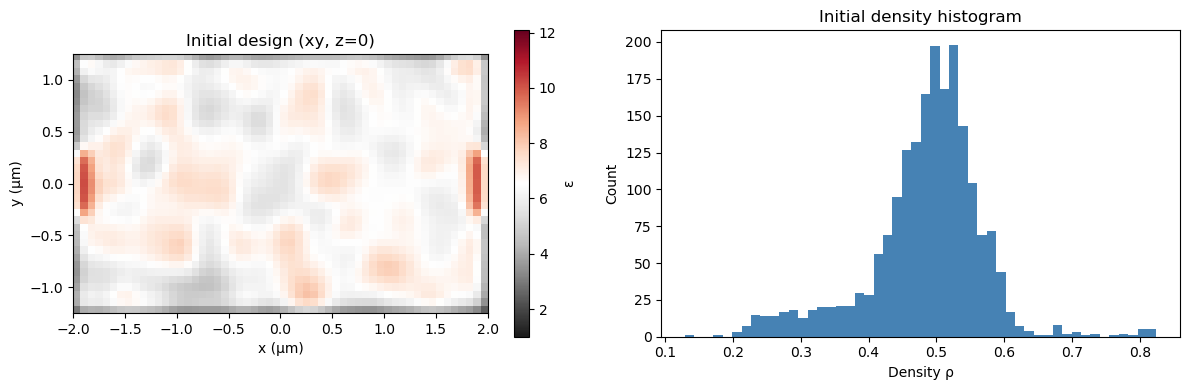

Npar = 1,960  |  init_par ∈ [0.316, 0.713]


In [11]:
# Section 11 — Initial design visualisation

np.random.seed(42)
init_par = np.random.uniform(0, 1, Npar)
init_par = ndi.gaussian_filter(init_par.reshape(Nx, Ny), sigma=1.5).ravel()
init_par = np.clip(init_par, 0, 1)

rho_init = pre_process(init_par, beta=beta_min).reshape(Nx, Ny)
eps_init = eps_air + (eps_Si - eps_air) * rho_init

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)

im = ax0.imshow(eps_init.T, extent=[-dr_lx/2, dr_lx/2, -dr_ly/2, dr_ly/2],
                origin="lower", cmap="RdGy_r", vmin=eps_air, vmax=eps_Si)
plt.colorbar(im, ax=ax0, label="ε")
ax0.set_title("Initial design (xy, z=0)"); ax0.set_xlabel("x (µm)"); ax0.set_ylabel("y (µm)")

ax1.hist(rho_init.ravel(), bins=50, color="steelblue", edgecolor="none")
ax1.set_xlabel("Density ρ"); ax1.set_ylabel("Count"); ax1.set_title("Initial density histogram")

plt.show()
print(f"Npar = {Npar:,}  |  init_par ∈ [{init_par.min():.3f}, {init_par.max():.3f}]")


In [12]:
# Section 12 — Checkpoint management

def save_history(h):
    with open(history_fname, "wb") as fh:
        pickle.dump(h, fh)

def load_history():
    with open(history_fname, "rb") as fh:
        return pickle.load(fh)

try:
    history = load_history()
    params   = history["params"][-1].copy()
    num_done = len(history["J"])
    print(f"Loaded checkpoint: {num_done}/{opt_steps} iterations done.")
    if num_done >= opt_steps:
        print("Optimisation already complete.")
    else:
        print("Resuming optimisation.")
except FileNotFoundError:
    params  = init_par.copy()
    history = dict(J=[], params=[], grad=[], beta=[], U_meas=[],
                   Fh=[], Tavg=[], Uerr=[], Penalty=[])
    print("No checkpoint found — starting fresh.")


No checkpoint found — starting fresh.


In [13]:
# Section 13 — Main evaluation: J, gradient, and U_meas
#
# Each call runs exactly two FDTD+adjoint simulations (TE input, TM input).
# No extra calibration runs are needed.
#
# Per-column amplitude normalization
# -----------------------------------
# Divide each output column vector by its own Euclidean norm so that the
# columns of U_meas are unit vectors (lossless normalization).  This places
# U_meas on the same O(1) scale as U_target regardless of MEEP's internal
# source normalization convention.
#
# Gradient scaling: the adjoint returns d(J_raw)/d(rho) where J_raw uses
# unnormalized amplitudes.  After dividing amplitudes by norm_col, the
# normalized objective is J_norm = J_raw / norm_col².  Therefore:
#   d(J_norm)/d(rho) = d(J_raw)/d(rho) / norm_col²
# We apply this per-column scale before summing and chain-ruling through
# the preprocessing pipeline.

def evaluate_and_grad(params_flat, beta, lambda_pen_val, step_num=None):
    """
    Run two FDTD sims (TE input, TM input) and return (J, grad, info_dict).

    Parameters
    ----------
    params_flat    : np.ndarray, shape (Npar,), values in [0, 1]
    beta           : float, projection sharpness
    lambda_pen_val : float, fabrication penalty weight
    step_num       : int or str, optional, for logging

    Returns
    -------
    J     : float, objective to maximise
    grad  : np.ndarray, shape (Npar,), dJ/d(params_flat)
    info  : dict with diagnostic scalars and U_meas
    """
    # ── 1. Preprocess design variables ──────────────────────────────────────
    rho = pre_process(params_flat, beta)

    # ── 2. TE-input simulation ───────────────────────────────────────────────
    f_te_raw, grad_te, a_te_TE, a_tm_TE = _get_raw_amplitudes(opt_TE, rho)

    # Per-column normalization: scale so the output column is a unit vector.
    norm_TE = np.sqrt(abs(a_te_TE)**2 + abs(a_tm_TE)**2 + 1e-30)
    a_te_TE /= norm_TE
    a_tm_TE /= norm_TE

    # ── 3. TM-input simulation ───────────────────────────────────────────────
    f_tm_raw, grad_tm, a_te_TM, a_tm_TM = _get_raw_amplitudes(opt_TM, rho)

    norm_TM = np.sqrt(abs(a_te_TM)**2 + abs(a_tm_TM)**2 + 1e-30)
    a_te_TM /= norm_TM
    a_tm_TM /= norm_TM

    # ── 4. Construct measured unitary matrix ─────────────────────────────────
    # U_meas[row, col]: row = output mode (TE=0, TM=1), col = input (TE=0, TM=1)
    U_meas = np.array([
        [a_te_TE, a_te_TM],
        [a_tm_TE, a_tm_TM],
    ], dtype=complex)

    # ── 5. Objective: |Tr(U_target† U_meas)|² / 4 ───────────────────────────
    # Gauge-invariant fidelity F ∈ [0, 1]; peak = 1 when U_meas = e^{iφ} U_target.
    inner    = np.trace(U_target.conj().T @ U_meas)
    fidelity = float(np.abs(inner)**2 / 4.0)

    # Transmission and unitarity diagnostics (on normalized U_meas)
    Tavg = float(np.linalg.norm(U_meas, 'fro')**2 / 2.0)
    Uerr = float(np.linalg.norm(U_meas.conj().T @ U_meas - np.eye(2), 'fro'))

    # ── 6. Fabrication penalty ───────────────────────────────────────────────
    pen = fab_penalty(params_flat, beta)

    # ── 7. Combined objective ────────────────────────────────────────────────
    J = fidelity - lambda_pen_val * pen

    # ── 8. Gradient ──────────────────────────────────────────────────────────
    # Raw adjoint gradient for each column is d(J_col_raw)/d(rho).
    # After per-column normalization the effective gradient scales by 1/norm².
    # Sum the two column contributions and divide by 4 (the |Tr|²/4 factor).
    dF_drho = (grad_te / norm_TE**2 + grad_tm / norm_TM**2) / 4.0

    # Chain-rule through the preprocessing pipeline
    grad = pre_process_grad(params_flat, dF_drho.ravel(), beta)

    # ── 9. Logging ───────────────────────────────────────────────────────────
    tag = f"step {step_num}" if step_num is not None else "eval"
    np.set_printoptions(precision=3, suppress=True)
    print(f"[{tag}] J={J:.4f} | F={fidelity:.4f} | Tavg={Tavg:.4f} | "
          f"Uerr={Uerr:.4f} | Penalty={pen:.4f} | beta={beta:.1f}")
    print(f"  U_meas =\n{U_meas}")

    info = {
        "J":       float(np.real(J)),
        "Fh":      fidelity,
        "Tavg":    Tavg,
        "Uerr":    Uerr,
        "Penalty": pen,
        "U":       U_meas.copy(),
    }

    return J, grad, info

print("evaluate_and_grad() defined.")


evaluate_and_grad() defined.


In [ ]:
# Section 14 — Optimisation loop (NLopt LD_MMA)
#
# NLopt LD_MMA (Method of Moving Asymptotes) is a standard algorithm for
# large-scale topology-optimisation problems with box constraints.
# NLopt convention: set_max_objective → grad[:] receives dJ/dx (positive direction).

iteration_counter = [len(history["J"])]

def nlopt_callback(x, grad):
    i = iteration_counter[0]
    print(f"\n{'='*55}\nIteration {i+1}/{opt_steps}")

    # Beta schedule: hold at beta_min for first beta_ramp_start iters, then ramp
    if i < beta_ramp_start:
        current_beta = beta_min
    else:
        frac = (i - beta_ramp_start) / max(1, opt_steps - 1 - beta_ramp_start)
        current_beta = beta_min + (beta_max - beta_min) * min(frac, 1.0)

    # Lambda schedule: ramp fabrication penalty weight from 0 to lambda_pen_max
    current_lambda_pen = lambda_pen_max * min(i / max(1, opt_steps - 1), 1.0)

    J_val, grad_val, info = evaluate_and_grad(
        params_flat    = x,
        beta           = current_beta,
        lambda_pen_val = current_lambda_pen,
        step_num       = i + 1,
    )

    # NLopt in-place gradient copy
    if grad.size > 0:
        grad[:] = grad_val

    # Compute standard Hadamard fidelity (|Tr|²/4) for logging
    U_meas = info["U"]
    trace_val = np.trace(U_target.conj().T @ U_meas)
    Fh_val    = float(abs(trace_val)**2 / 4.0)
    Tavg_val  = float(np.linalg.norm(U_meas, 'fro')**2 / 2.0)
    Uerr_val  = float(np.linalg.norm(U_meas.conj().T @ U_meas - np.eye(2), 'fro'))
    pen_val = info["Penalty"]

    # Append to history
    history["J"].append(float(J_val))
    history["params"].append(x.copy())
    history["grad"].append(grad_val.copy())
    history["beta"].append(float(current_beta))
    history["U_meas"].append(U_meas.copy())
    history["Fh"].append(Fh_val)
    history["Tavg"].append(Tavg_val)
    history["Uerr"].append(Uerr_val)
    history["Penalty"].append(pen_val)

    save_history(history)
    iteration_counter[0] += 1
    return float(J_val)


# Configure and launch NLopt
remaining = opt_steps - len(history["J"])
if remaining > 0:
    opt_nlopt = nlopt.opt(nlopt.LD_MMA, Npar)
    opt_nlopt.set_lower_bounds(0.0)
    opt_nlopt.set_upper_bounds(1.0)
    opt_nlopt.set_max_objective(nlopt_callback)
    opt_nlopt.set_maxeval(remaining)
    opt_nlopt.set_ftol_rel(1e-6)

    print(f"Starting NLopt MMA from iteration {len(history['J'])+1}…")
    params = opt_nlopt.optimize(params.copy())
    print(f"\nOptimisation finished.  Final J = {opt_nlopt.last_optimum_value():.4f}")
else:
    print("Optimisation complete (loaded from checkpoint).")


Starting NLopt MMA from iteration 1…

Iteration 1/5
Starting forward run...
-----------
Initializing structure...
time for choose_chunkdivision = 0.000537195 s
Working in 3D dimensions.
Computational cell is 8 x 4.5 x 3.21429 with resolution 14
     block, center = (0,0,-0.61)
          size (1e+06,1e+06,1)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.08514,2.08514,2.08514)
     block, center = (-3.005,0,0)
          size (2.02,0.5,0.22)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.0826,12.0826,12.0826)
     block, center = (3.005,0,0)
          size (2.02,0.5,0.22)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.0826,12.0826,12.0826)
     block, center = (0,0,0)
          size (4,2.5,0.22)
          axes (1,0,0), (0,1,0), (0,0,1)
time for set_epsilon = 0.164983 s
-----------


MPB solved for frequency_1(2.24258,0,0) = 0.874094 after 26 iters
MPB solved for frequency_1(1.34772,0,0) = 0.650867 after 14 iters
MPB solved for frequency_1(1.32421,0,0) = 0.645164 after 10 iters
MPB solved for frequency_1(1.32419,0,0) = 0.645161 after 3 iters
on time step 251 (time=8.96429), 0.0159603 s/step
on time step 589 (time=21.0357), 0.0118443 s/step
on time step 928 (time=33.1429), 0.0118256 s/step
on time step 1266 (time=45.2143), 0.0118499 s/step
on time step 1607 (time=57.3929), 0.0117308 s/step
on time step 1947 (time=69.5357), 0.011776 s/step
on time step 2291 (time=81.8214), 0.0116323 s/step
on time step 2636 (time=94.1429), 0.0116112 s/step
on time step 2979 (time=106.393), 0.0116618 s/step
on time step 3319 (time=118.536), 0.0117787 s/step
on time step 3660 (time=130.714), 0.0117556 s/step
on time step 3994 (time=142.643), 0.0119821 s/step
on time step 4331 (time=154.679), 0.0118695 s/step
on time step 4665 (time=166.607), 0.011986 s/step
on time step 4999 (time=178.

run 0 finished at t = 851.75 (23849 timesteps)
MPB solved for frequency_1(0.645161,0,0) = 0.457952 after 28 iters
MPB solved for frequency_1(1.06552,0,0) = 0.582445 after 15 iters
MPB solved for frequency_1(1.32179,0,0) = 0.644579 after 13 iters
MPB solved for frequency_1(1.32419,0,0) = 0.645161 after 8 iters
MPB solved for frequency_1(1.32419,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.324195,-0.000000,0.000000)


MPB solved for frequency_2(0.645161,0,0) = 0.488469 after 28 iters
MPB solved for frequency_2(0.918521,0,0) = 0.624031 after 18 iters
MPB solved for frequency_2(0.968323,0,0) = 0.644564 after 16 iters
MPB solved for frequency_2(0.969813,0,0) = 0.645161 after 11 iters
MPB solved for frequency_2(0.969815,0,0) = 0.645161 after 2 iters
Dominant planewave for band 2: (0.969815,-0.000000,0.000000)
Starting adjoint run...


MPB solved for frequency_1(-0.645161,0,0) = 0.457952 after 28 iters
MPB solved for frequency_1(-1.06552,0,0) = 0.582445 after 15 iters
MPB solved for frequency_1(-1.32179,0,0) = 0.644579 after 13 iters
MPB solved for frequency_1(-1.32419,0,0) = 0.645161 after 8 iters
MPB solved for frequency_1(-1.32419,0,0) = 0.645161 after 1 iters


...

run 4 finished at t = 856.4642857142857 (23981 timesteps)
MPB solved for frequency_1(0.645161,0,0) = 0.457952 after 28 iters
MPB solved for frequency_1(1.06552,0,0) = 0.582445 after 15 iters
MPB solved for frequency_1(1.32179,0,0) = 0.644579 after 13 iters
MPB solved for frequency_1(1.32419,0,0) = 0.645161 after 8 iters
MPB solved for frequency_1(1.32419,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.324195,-0.000000,0.000000)


MPB solved for frequency_2(0.645161,0,0) = 0.488469 after 28 iters
MPB solved for frequency_2(0.918521,0,0) = 0.624031 after 18 iters
MPB solved for frequency_2(0.968323,0,0) = 0.644564 after 16 iters
MPB solved for frequency_2(0.969813,0,0) = 0.645161 after 11 iters
MPB solved for frequency_2(0.969815,0,0) = 0.645161 after 2 iters
Dominant planewave for band 2: (0.969815,-0.000000,0.000000)
Starting adjoint run...


MPB solved for frequency_1(-0.645161,0,0) = 0.457952 after 28 iters
MPB solved for frequency_1(-1.06552,0,0) = 0.582445 after 15 iters
MPB solved for frequency_1(-1.32179,0,0) = 0.644579 after 13 iters
MPB solved for frequency_1(-1.32419,0,0) = 0.645161 after 8 iters
MPB solved for frequency_1(-1.32419,0,0) = 0.645161 after 1 iters


MPB solved for frequency_2(-0.645161,0,0) = 0.488469 after 29 iters
MPB solved for frequency_2(-0.918521,0,0) = 0.624031 after 18 iters
MPB solved for frequency_2(-0.968323,0,0) = 0.644564 after 16 iters
MPB solved for frequency_2(-0.969813,0,0) = 0.645161 after 11 iters
MPB solved for frequency_2(-0.969815,0,0) = 0.645161 after 2 iters
on time step 228 (time=8.14286), 0.0175556 s/step
on time step 457 (time=16.3214), 0.0175104 s/step
on time step 687 (time=24.5357), 0.0174287 s/step
on time step 921 (time=32.8929), 0.0171662 s/step
on time step 1150 (time=41.0714), 0.0174971 s/step
on time step 1377 (time=49.1786), 0.0176268 s/step
on time step 1611 (time=57.5357), 0.017144 s/step
on time step 1845 (time=65.8929), 0.0171006 s/step
on time step 2078 (time=74.2143), 0.0171746 s/step
on time step 2313 (time=82.6071), 0.0170473 s/step
on time step 2547 (time=90.9643), 0.0170998 s/step
on time step 2781 (time=99.3214), 0.0171284 s/step
on time step 3015 (time=107.679), 0.0171291 s/step
on 

MPB solved for frequency_1(2.24258,0,0) = 0.874094 after 26 iters
MPB solved for frequency_1(1.34772,0,0) = 0.650867 after 14 iters
MPB solved for frequency_1(1.32421,0,0) = 0.645164 after 10 iters
MPB solved for frequency_1(1.32419,0,0) = 0.645161 after 3 iters
on time step 177 (time=6.32143), 0.022672 s/step
on time step 407 (time=14.5357), 0.0174646 s/step
on time step 639 (time=22.8214), 0.017264 s/step
on time step 871 (time=31.1071), 0.0172451 s/step
on time step 1102 (time=39.3571), 0.0173308 s/step
on time step 1335 (time=47.6786), 0.0172241 s/step
on time step 1563 (time=55.8214), 0.0175936 s/step
on time step 1787 (time=63.8214), 0.0179165 s/step
on time step 2012 (time=71.8571), 0.0178243 s/step
on time step 2243 (time=80.1071), 0.0173302 s/step
on time step 2475 (time=88.3929), 0.0172417 s/step
on time step 2708 (time=96.7143), 0.0172258 s/step
on time step 2974 (time=106.214), 0.015073 s/step
on time step 3217 (time=114.893), 0.016517 s/step
on time step 3448 (time=123.143

In [ ]:
# Section 15 — Convergence plot + final design

J_vals    = np.array(history["J"])
Fh_vals   = np.array(history["Fh"])
Tavg_vals = np.array(history["Tavg"])
Uerr_vals = np.array(history["Uerr"])
Pen_vals  = np.array(history["Penalty"])
final_par  = history["params"][-1]
final_beta = history["beta"][-1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), tight_layout=True)

axes[0].plot(J_vals,    "k-",  label="J (objective)")
axes[0].plot(Fh_vals,   "r--", label="Fidelity F")
axes[0].plot(Tavg_vals, "b:",  label="Avg transmission")
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Score")
axes[0].set_title("Convergence"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(Uerr_vals, "m-",  label="Unitarity error")
axes[1].plot(Pen_vals,  "g-.", label="Fab penalty")
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("Residual")
axes[1].set_title("Constraint residuals"); axes[1].legend(); axes[1].grid(True)

rho_final = pre_process(final_par, final_beta).reshape(Nx, Ny)
eps_final = eps_air + (eps_Si - eps_air) * rho_final
im = axes[2].imshow(eps_final.T, extent=[-dr_lx/2, dr_lx/2, -dr_ly/2, dr_ly/2],
                    origin="lower", cmap="RdGy_r", vmin=eps_air, vmax=eps_Si)
plt.colorbar(im, ax=axes[2], label="ε")
axes[2].set_title(f"Final design (β={final_beta:.1f})")
axes[2].set_xlabel("x (µm)"); axes[2].set_ylabel("y (µm)")

plt.show()


In [ ]:
# Section 16 — Verification: measure U_meas on the binarised final design
#
# Run two forward sims at beta=100 (≈ step function) with lambda_pen=0
# to extract the purely optical performance metrics.

print("="*60)
print("RUNNING FINAL BINARIZED VERIFICATION")
print("="*60)

_, _, verify_info = evaluate_and_grad(
    params_flat    = final_par,
    beta           = 100.0,
    lambda_pen_val = 0.0,
    step_num       = "VERIFY",
)

U_final          = verify_info["U"]
fidelity_final   = verify_info["Fh"]
transmission_final = verify_info["Tavg"]
unitarity_residual = float(np.linalg.norm(U_final.conj().T @ U_final - np.eye(2), "fro"))

print("\n" + "="*60)
print("FINAL DEVICE PERFORMANCE")
print("="*60)
print("U_target =")
print(np.round(U_target, 4))
print("\nU_meas (binarised) =")
print(np.round(U_final, 4))
print("\n|U_target − U_meas| (elementwise) =")
print(np.round(np.abs(U_target - U_final), 4))
print("-"*60)
print(f"Fidelity  F = |Tr(U†U_meas)|²/4  = {fidelity_final:.4f}   (ideal = 1.0)")
print(f"Transmission T = ‖U‖²_F / 2      = {transmission_final:.4f}  (lossless = 1.0)")
print(f"Unitarity residual ‖U†U − I‖_F   = {unitarity_residual:.4f}  (ideal = 0.0)")
print("="*60)


In [ ]:
# Section 17 — State-by-state verification
#
# Since the full 2×2 matrix U_meas has been measured analytically,
# per-state fidelity is evaluated without additional FDTD runs.

states = {
    "TE"    : np.array([1.0,  0.0],         dtype=complex),
    "TM"    : np.array([0.0,  1.0],         dtype=complex),
    "diag+" : np.array([1.0,  1.0],         dtype=complex) / np.sqrt(2),
    "diag-" : np.array([1.0, -1.0],         dtype=complex) / np.sqrt(2),
    "Rcirc" : np.array([1.0,  1j],          dtype=complex) / np.sqrt(2),
    "Lcirc" : np.array([1.0, -1j],          dtype=complex) / np.sqrt(2),
}

print(f"{'state':<8}  {'F_state':>8}  |ψ_meas|    |ψ_target|")
print("-" * 50)
for name, psi_in in states.items():
    psi_out_target = U_target @ psi_in
    psi_out_meas   = U_final  @ psi_in
    F = float(
        abs(np.vdot(psi_out_target, psi_out_meas))**2 /
        (np.vdot(psi_out_target, psi_out_target).real
         * np.vdot(psi_out_meas,  psi_out_meas ).real + 1e-30)
    )
    print(f"{name:<8}  {F:>8.4f}  "
          f"[{abs(psi_out_meas[0]):.3f}, {abs(psi_out_meas[1]):.3f}]  "
          f"[{abs(psi_out_target[0]):.3f}, {abs(psi_out_target[1]):.3f}]")


In [ ]:
# Section 18 — Analytical R-D-R decomposition cross-check
#
# Hadamard = R(-π/4) D(π) R(π/4)  up to a global phase.
# Verify the phase match.

U_cascade   = rotator(-np.pi/4) @ retarder(np.pi) @ rotator(np.pi/4)
phase_match = float(abs(np.trace(U_target.conj().T @ U_cascade))**2 / 4.0)

print("Analytical cascade  U = R(-π/4) D(π) R(π/4) =")
print(np.round(U_cascade, 4))
print()
print(f"|Tr(U_target† U_cascade)|²/4 = {phase_match:.6f}  (1.0 = same up to global phase)")
print()
print("The inverse-designed device, the R-D-R cascade, and the Hadamard target")
print("all implement the same operation up to an irrelevant global phase.")


In [ ]:
# Section 19 — Final design export and summary

rho_bin = (pre_process(final_par, final_beta).reshape(Nx, Ny) >= 0.5).astype(int)
np.savetxt("misc/polarization_unitary_meepv5_design.csv", rho_bin, fmt="%d", delimiter=",")

fig, ax = plt.subplots(figsize=(8, 4), tight_layout=True)
ax.imshow(rho_bin.T, extent=[-dr_lx/2, dr_lx/2, -dr_ly/2, dr_ly/2],
          origin="lower", cmap="binary", vmin=0, vmax=1)
ax.set_title("Final binarised design  (black = Si, white = air)")
ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
plt.show()

print("="*60)
print("Final summary")
print("="*60)
print(f"Target unitary      : Hadamard")
print(f"Wavelength          : {wl} µm")
print(f"Design region       : {dr_lx} µm × {dr_ly} µm,  {Nx}×{Ny} pixels")
print(f"Optimisation iters  : {len(history['J'])}")
print(f"Final J             : {history['J'][-1]:.4f}")
print(f"Final Fidelity F    : {history['Fh'][-1]:.4f}  (perfect = 1.0)")
print(f"Verification F      : {fidelity_final:.4f}  (perfect = 1.0)")
print(f"Verification Tavg   : {transmission_final:.4f}  (lossless = 1.0)")
print(f"Unitarity residual  : {unitarity_residual:.4f}  (ideal = 0.0)")
print(f"Design CSV          : misc/polarization_unitary_meepv5_design.csv")
